# North Shore Volcanic Group ca. 1095 Ma paleomagnetic pole

## Geologic context

The North Shore Volcanic Group (NSVG) is the thick succession of subaerial
tholeiitic to icelanditic lava flows and minor interflow sediments that crops
out along the northwest shore of Lake Superior in Minnesota, erupted during the
main magmatic stage of the Midcontinent Rift. The flows dip gently toward the
rift axis (southeast) and are exposed along the two limbs of the Lake Superior
syncline, so the group is described in terms of an upper southwest (SW) sequence
and an upper northeast (NE) sequence that record the same Portage Lake
normal-polarity zone, together with older lower and reversed-polarity flows.

The reversal stratigraphy and the U-Pb geochronology of Swanson-Hysell et al.
(2019) place the normally magnetized upper sequences at ca. 1093-1097 Ma: a
\(^{206}\)Pb/\(^{238}\)U date on the 40th Ave. Icelandite (1096.75 \(\pm\) 0.28 Ma)
provides a lower bound for the SW sequence, the Two Harbors Icelandite
(1096.18 \(\pm\) 0.32 Ma) lies within it, and the Palisade Rhyolite
(1093.94 \(\pm\) 0.28 Ma) provides an upper bound; the Grand Marais Rhyolite
(1093.38 \(\pm\) 0.55 Ma) is near the top of the NE sequence, which also post-dates
the Devil's Kettle Rhyolite (1097.7 \(\pm\) 2.2 Ma; Davis and Green, 1997).

## Pole

Following the prior Nordic compilation (GPMDB 9856), a single combined
normal-polarity NSVG pole is computed here from all of the normal-polarity lava
flows of the upper sequences (above the basal unconformity, excluding intrusions
and the older reversed flows). The upper SW and upper NE sub-sequences are
also computed and plotted for context. Site
directions are from Tauxe and Kodama (2009), Books (1972), and the new Gooseberry
River section data of Swanson-Hysell et al. (2019).

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data: the full sites-to-pole workflow

The three source site tables (copied into `contribution_build/` from the
APWP_StratModels compilation, which mirrors the published data) are loaded and
the NSVG stratigraphic sub-sequences selected by their Tauxe and Kodama (2009)
(`ns###`) and Books (1972) (`NS###`) site identifiers. Tauxe and Kodama (2009)
report separate magnetite (`MAG`) and hematite (`HEM`) components for some sites;
following the Swanson-Hysell et al. (2019) compilation all reported components in
tilt-corrected coordinates are retained. Virtual geomagnetic poles (VGPs) are
computed from the tilt-corrected site directions.

In [2]:
CB = '../data/1095_North_Shore_Volcanic_Group/contribution_build/'

# --- Tauxe and Kodama (2009): the comprehensive NSVG site survey -------------
tauxe = pd.read_csv(CB + 'Tauxe2009_NSVG_sites_source.txt', sep='\t', skiprows=1)
tauxe = tauxe[tauxe['dir_tilt_correction'] == 100].reset_index(drop=True)
tauxe = ipmag.vgp_calc(tauxe, site_lon='lon', site_lat='lat', tilt_correction='yes',
                       dec_tc='dir_dec', inc_tc='dir_inc')
tauxe['citations'] = 'Tauxe and Kodama, 2009'

# --- Books (1972): additional NE-sequence flows (VGPs supplied in the table) --
books = pd.read_csv(CB + 'Books1972_NSVG_sites_source.txt', sep='\t', header=1)
books['citations'] = 'Books, 1972'

# --- Swanson-Hysell et al. (2019): Gooseberry River section (SW sequence) -----
goose = pd.read_csv(CB + 'SH2019a_Gooseberry_sites_source.txt', sep='\t', header=1)
goose = goose[(goose['dir_comp_name'] == 'HT') &
              (goose['dir_tilt_correction'] == 100.0) &
              (goose['site'] != 'GB5')].reset_index(drop=True)
goose['citations'] = 'Swanson-Hysell et al., 2019'

print(f'Tauxe & Kodama (2009): {len(tauxe)} tilt-corrected components')
print(f'Books (1972):          {len(books)} NSVG sites')
print(f'Gooseberry (2019):     {len(goose)} HT site means')

Tauxe & Kodama (2009): 86 tilt-corrected components
Books (1972):          36 NSVG sites
Gooseberry (2019):     31 HT site means


In [3]:
# NSVG stratigraphic sub-sequences (site identifiers from the SH2019 compilation)
nswu = ['ns034','ns035','ns036','ns037','ns038','ns039','ns040','ns042','ns043',
        'ns044','ns045','ns046','ns047','ns048','ns049','ns050','ns051','ns052',
        'ns053','ns054','ns055','ns056','ns057','ns058','ns059','ns060','ns061',
        'ns062','ns063','ns064','ns065','ns066','ns067','ns068','ns071','ns072',
        'ns073','ns074','ns075','ns077','ns078','ns079','ns080','ns081','ns083',
        'ns085','ns087']                                   # upper SW (Tauxe)
nneu = ['ns002','ns003','ns004','ns005','ns016','ns018','ns019','ns020','ns021',
        'ns022','ns023','ns028','ns030','ns031','ns032']   # upper NE (Tauxe)
books_nneu = ['NS269','NS378','NS227','NS229','NS375','NS226','NS362','NS365',
              'NS367','NS265','NS370','NS371','NS372']     # upper NE (Books)

# The lower (nsl = ns006-ns015) and lower-NE reversed (nnel = ns024, ns026) Tauxe
# sites are NOT part of the NSVG pole: per Swanson-Hysell et al. (2019) the nsl
# flows belong to the overlying Schroeder-Lutsen basalts pole (see
# 1090_Schroeder_Lutsen_Basalts) and nnel to the Grand Portage pole. They are
# excluded from this notebook entirely.

def tag(df, sites, sequence, polarity):
    out = df[df['site'].isin(sites)].copy()
    out['sequence'] = sequence
    out['dir_polarity'] = polarity
    return out

# upper normal-polarity sequences (the pole)
sw_tauxe = tag(tauxe, nswu, 'upper SW', 'n')
ne_tauxe = tag(tauxe, nneu, 'upper NE', 'n')
ne_books = tag(books, books_nneu, 'upper NE', 'n')
goose['sequence'] = 'upper SW'; goose['dir_polarity'] = 'n'

# study locality for the combined pole (Gooseberry River reference, 9856 SLAT/SLON)
study_lat, study_lon = 46.3, 268.7

## Combined normal-polarity NSVG pole

The combined pole is the Fisher mean of the VGPs of every normal-polarity
upper-sequence flow (SW + NE, from all three studies). Books (1972) did not
report site-level Fisher statistics, so the study-mean precision is assigned to
those sites for the per-site columns; this does not affect the VGP-level pole.

In [4]:
COMMON = ['site','lat','lon','dir_dec','dir_inc','dir_k','dir_alpha95',
          'dir_n_samples','dir_tilt_correction','dir_polarity','vgp_lat','vgp_lon',
          'citations','sequence']

def harmonize(df):
    out = pd.DataFrame()
    for c in COMMON:
        out[c] = df[c] if c in df.columns else np.nan
    return out

# assign the Books (1972) study-mean Fisher stats to its sites (no site-level k)
books_dir = ipmag.fisher_mean(ne_books['dir_dec'].tolist(), ne_books['dir_inc'].tolist())
ne_books = ne_books.copy()
ne_books['dir_k'] = round(books_dir['k'], 1)
ne_books['dir_alpha95'] = round(books_dir['alpha95'], 1)

normal_upper = pd.concat([harmonize(sw_tauxe), harmonize(goose),
                          harmonize(ne_tauxe), harmonize(ne_books)],
                         ignore_index=True)
normal_upper['dir_tilt_correction'] = 100

vgp_block, pole_mean = pt.compute_mean_pole(normal_upper, unify_polarity=True)
ipmag.print_pole_mean(pole_mean)
print(f"\nprior compilation (GPMDB 9856): 34.5 N, 181.3 E, A95 2.8 (B=61, N=279)")

Plon: 180.1  Plat: 35.1
Number of directions in mean (n): 118
Angular radius of 95% confidence (A_95): 1.9
Precision parameter (k) estimate: 49.6

prior compilation (GPMDB 9856): 34.5 N, 181.3 E, A95 2.8 (B=61, N=279)


upper SW sequence: 36.7 N, 179.3 E, A95 2.1, N=87
upper NE sequence: 30.7 N, 182.0 E, A95 3.9, N=31


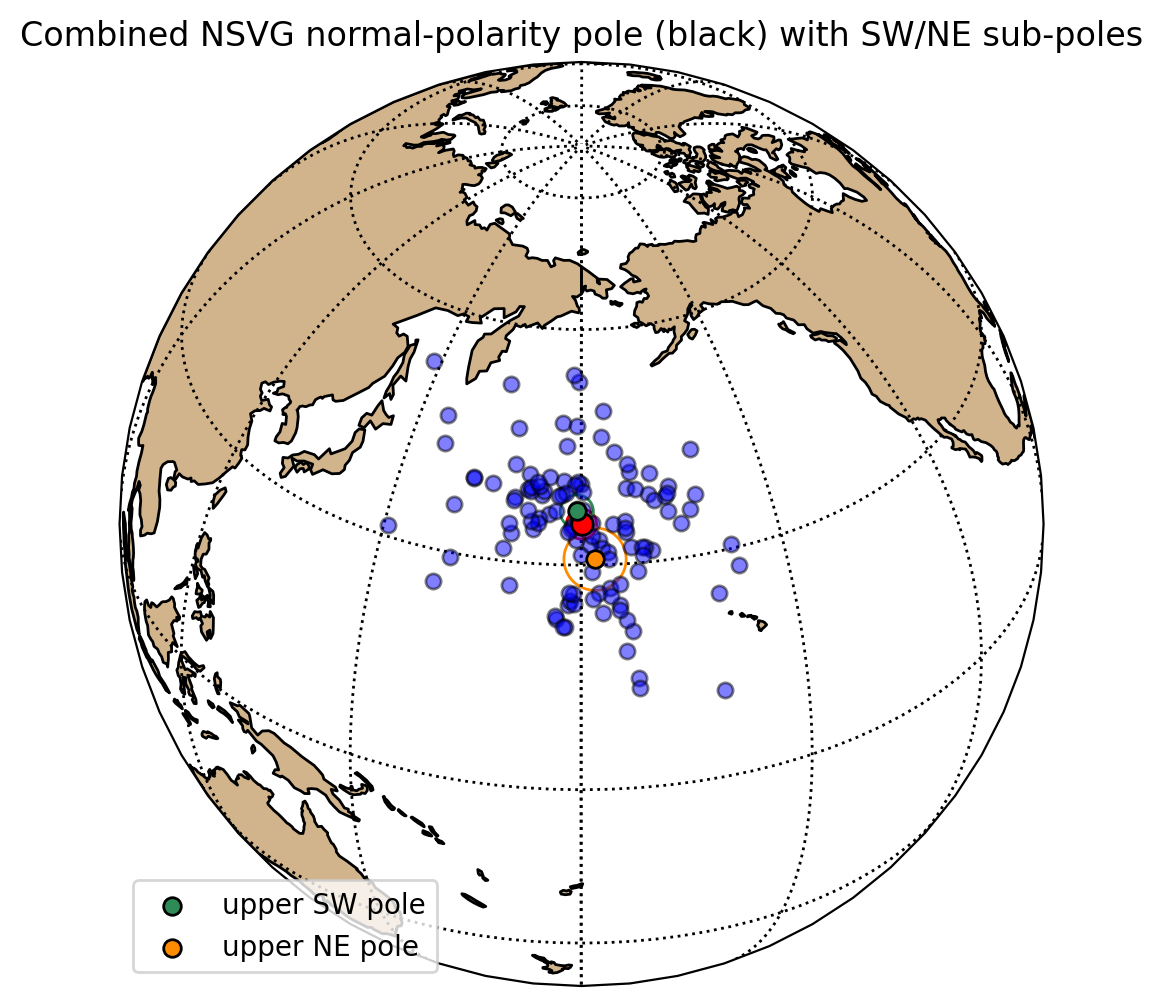

In [5]:
# sub-sequence poles (context) and the combined pole, on one orthographic plot
def subpole(df):
    return pt.compute_mean_pole(harmonize(df), unify_polarity=True)[1]

sw_pole = subpole(pd.concat([sw_tauxe, goose], ignore_index=True))
ne_pole = subpole(pd.concat([ne_tauxe, ne_books], ignore_index=True))
print(f"upper SW sequence: {sw_pole['inc']:.1f} N, {sw_pole['dec']:.1f} E, "
      f"A95 {sw_pole['alpha95']:.1f}, N={int(sw_pole['n'])}")
print(f"upper NE sequence: {ne_pole['inc']:.1f} N, {ne_pole['dec']:.1f} E, "
      f"A95 {ne_pole['alpha95']:.1f}, N={int(ne_pole['n'])}")

ax = pt.plot_vgps_and_pole(vgp_block, pole_mean,
                           central_longitude=pole_mean['dec'],
                           central_latitude=pole_mean['inc'], figsize=(6, 6))
ipmag.plot_pole(ax, sw_pole['dec'], sw_pole['inc'], sw_pole['alpha95'],
                color='seagreen', markersize=40, label='upper SW pole')
ipmag.plot_pole(ax, ne_pole['dec'], ne_pole['inc'], ne_pole['alpha95'],
                color='darkorange', markersize=40, label='upper NE pole')
ax.legend(loc='lower left')
plt.title('Combined NSVG normal-polarity pole (black) with SW/NE sub-poles')
plt.show()

## Mean direction (tilt-corrected)

Dec: 294.8  Inc: 43.3
Number of directions in mean (n): 118
Angular radius of 95% confidence (a_95): 1.9
Precision parameter (k) estimate: 47.4


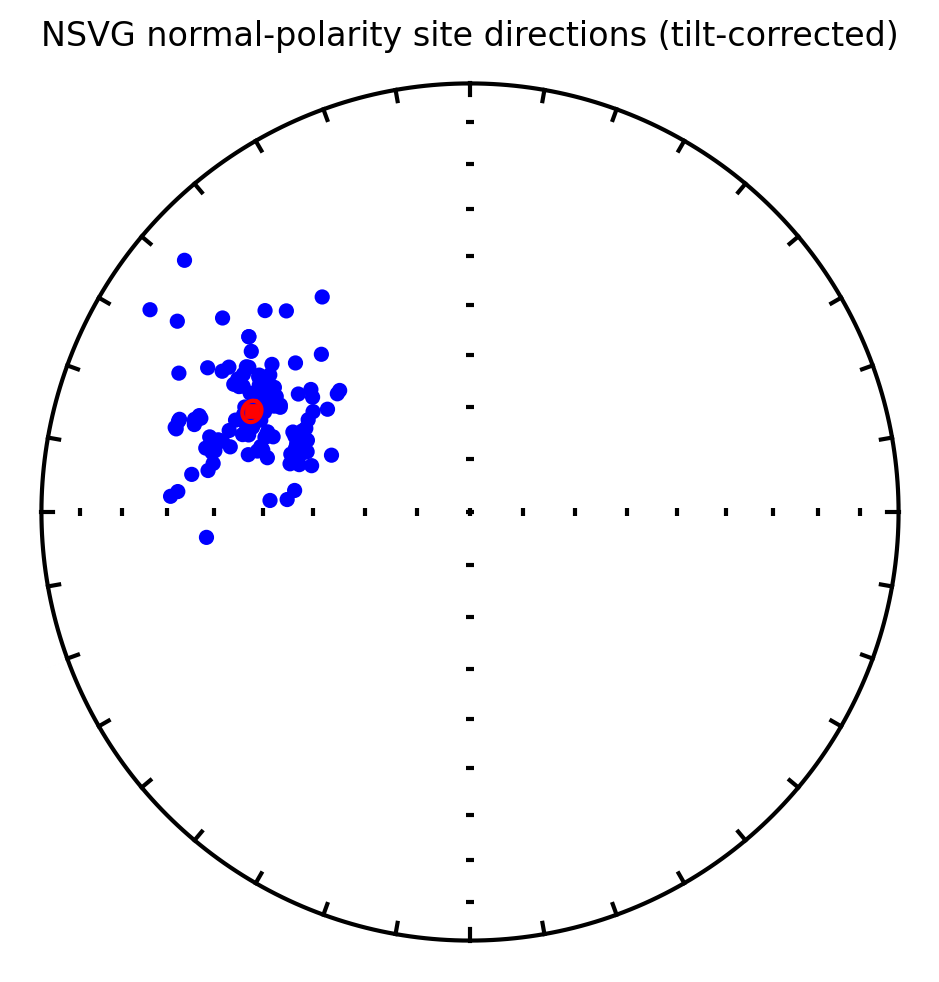

In [6]:
dir_block, dir_mean = pt.compute_mean_direction(normal_upper, unify_polarity=True)
ipmag.print_direction_mean(dir_mean)
ipmag.plot_net()
ipmag.plot_di(di_block=dir_block, color='blue', marker='o')
ipmag.plot_di_mean(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'],
                   color='red', marker='s')
plt.title('NSVG normal-polarity site directions (tilt-corrected)')
plt.show()

## Paleosecular variation and VGP-shape diagnostics

The combined pole is assessed for adequate averaging of paleosecular variation
with the Deenen et al. (2011) A95 envelope, a Fisher quantile-quantile test of
the VGP distribution, and the elongation/direction (SVEI) test against the
TK03.GAD field model.

A_95 of 1.9 passes Deenen et al. (2011) criteria of being between 1.8 and 4.1 for this number of sites


<AxesSubplot:title={'center':'Deenen et al. (2011) test'}, xlabel='Number of sites (N)', ylabel='$A_{95}$ (°)'>

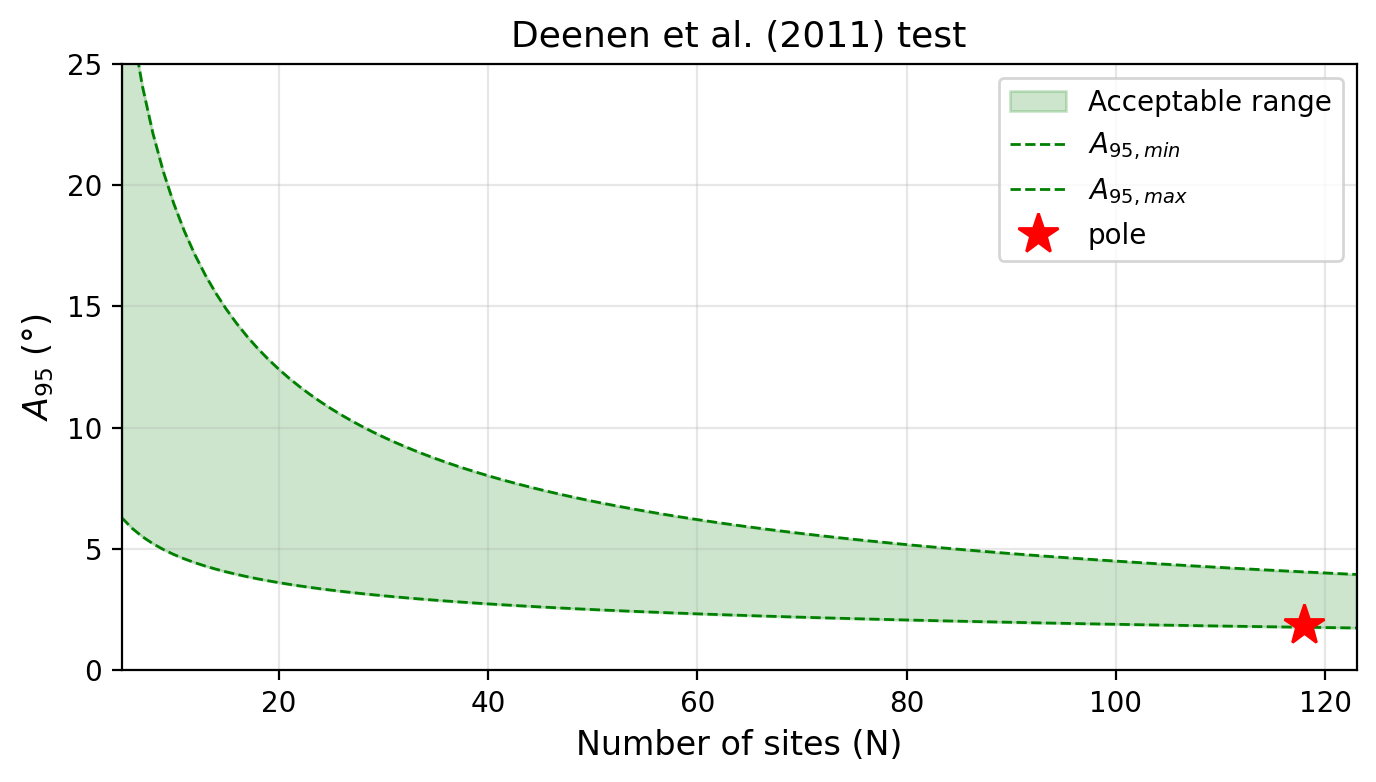

In [7]:
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
pt.plot_Deenen_test(pole_mean)

{'Mode': 'Mode 1',
 'Dec': 180.07144062941381,
 'Inc': 35.1182742131349,
 'N': 118,
 'Mu': 1.28488330084221,
 'Mu_critical': 1.207,
 'Me': 0.711404819240865,
 'Me_critical': 1.094,
 'Test_result': 'Fisher distribution rejected'}

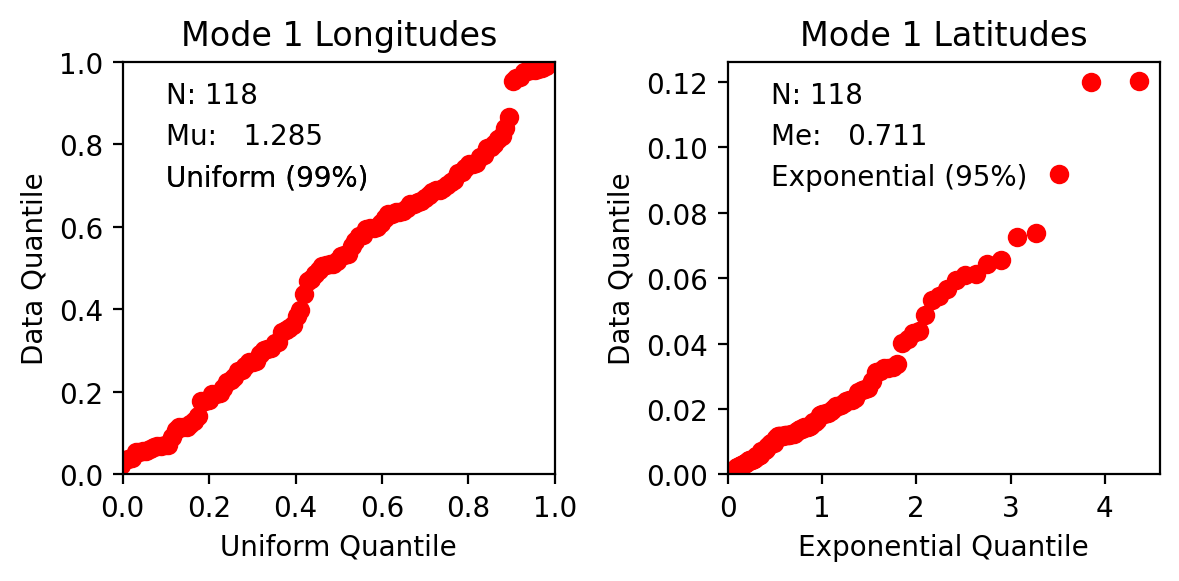

In [8]:
fishqq_result = pt.fishqq_vgps(normal_upper, unify_polarity=True)
fishqq_result

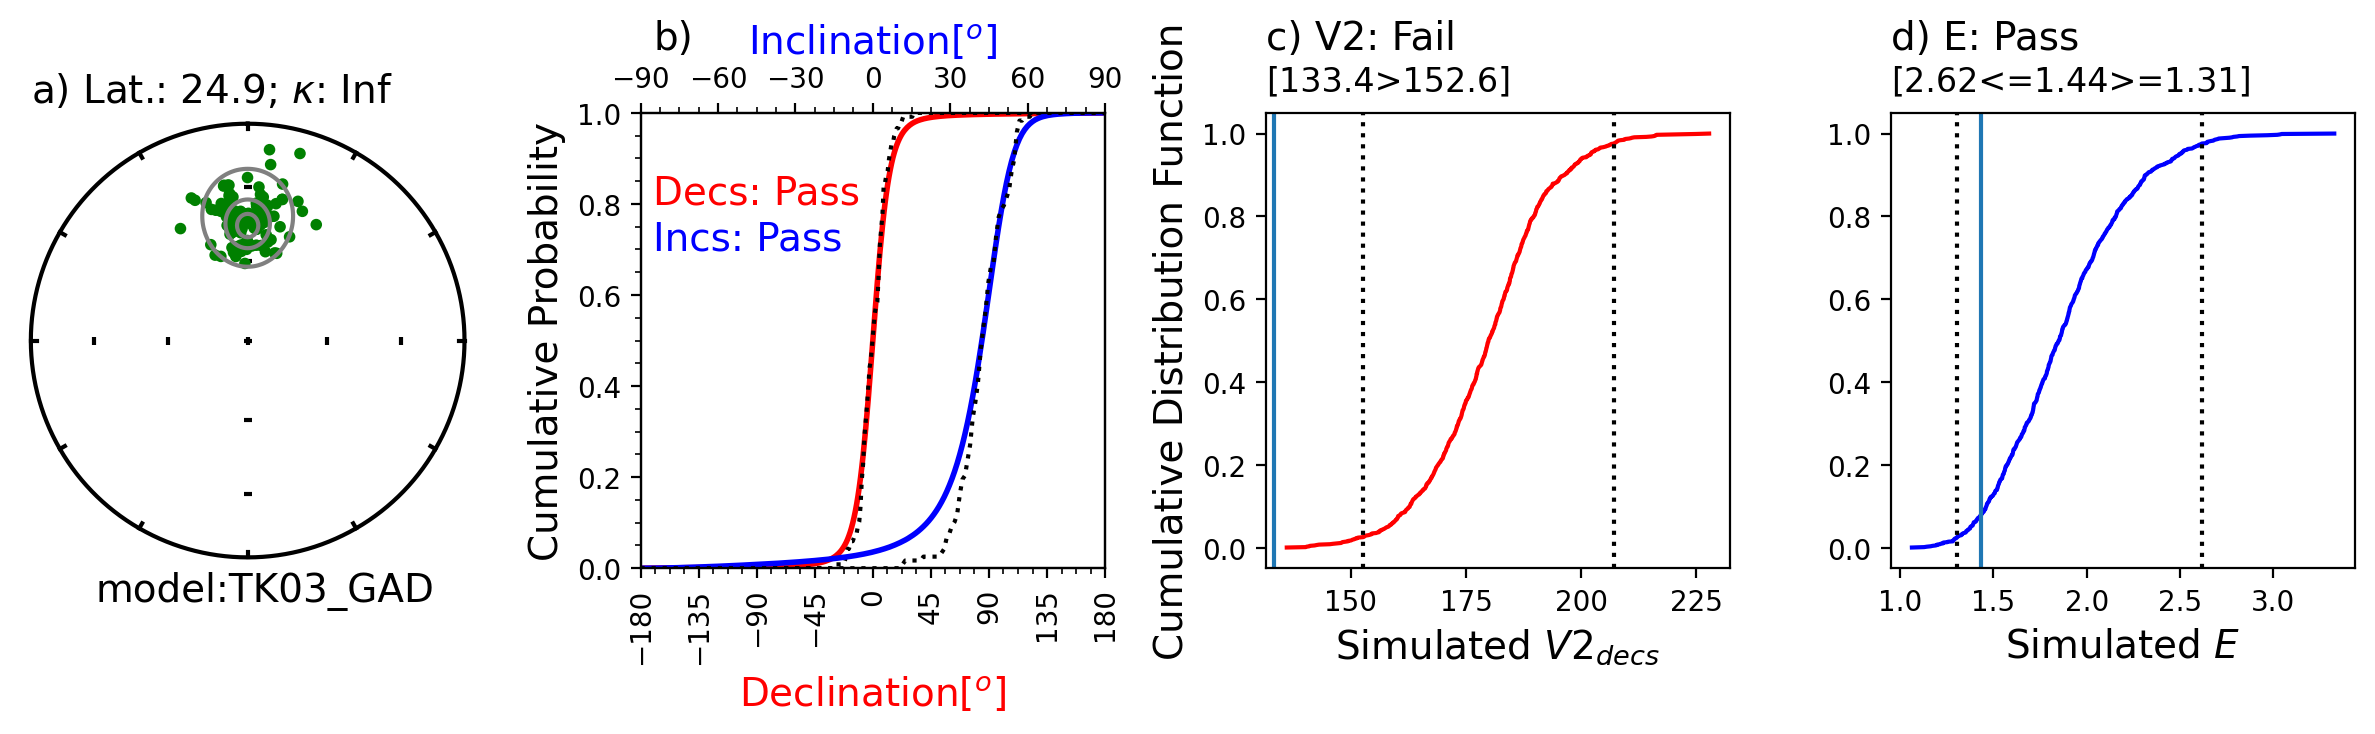

paleolatitude = 24.9 deg; elongation E = 1.44 (consistent with TK03.GAD)


In [9]:
svei_result = pt.svei_test_vgps(normal_upper, study_lon, study_lat,
                                model='TK03_GAD', plot=True)
print(f"paleolatitude = {svei_result['lat']:.1f} deg; elongation E = {svei_result['E']:.2f} "
      f"({'consistent' if svei_result['E_result'] else 'inconsistent'} with TK03.GAD)")

## The NSVG pole in the context of the Laurentia APWP

posx and posy should be finite values
posx and posy should be finite values


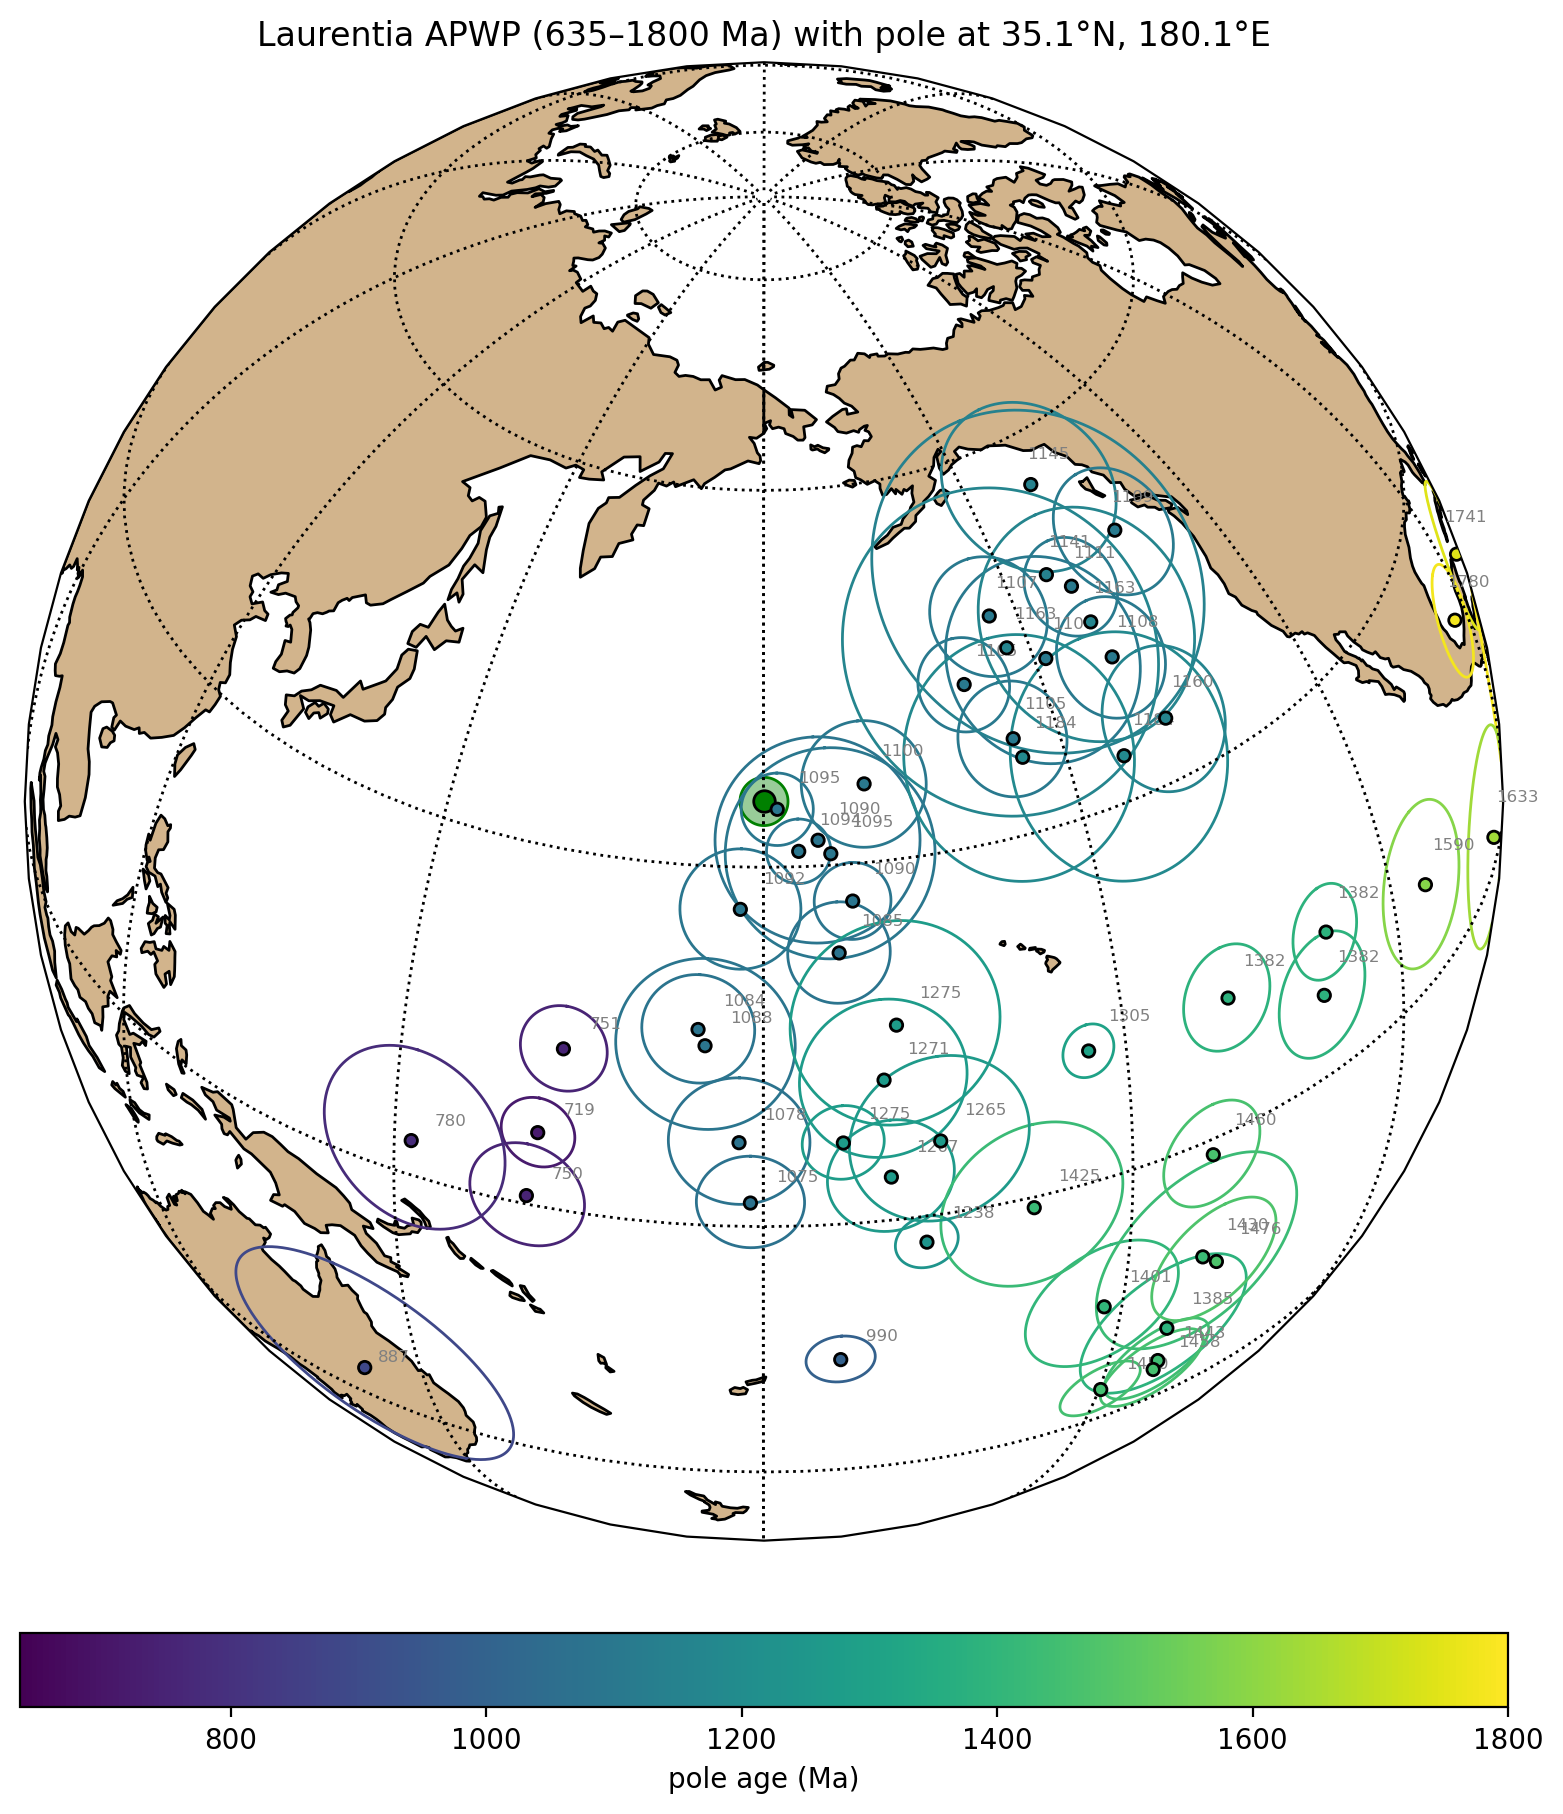

In [10]:
Laurentia_poles = pt.get_Laurentia_poles()
ax = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'],
                          pole_mean['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
plt.show()

## R7: comparison with younger Laurentia poles

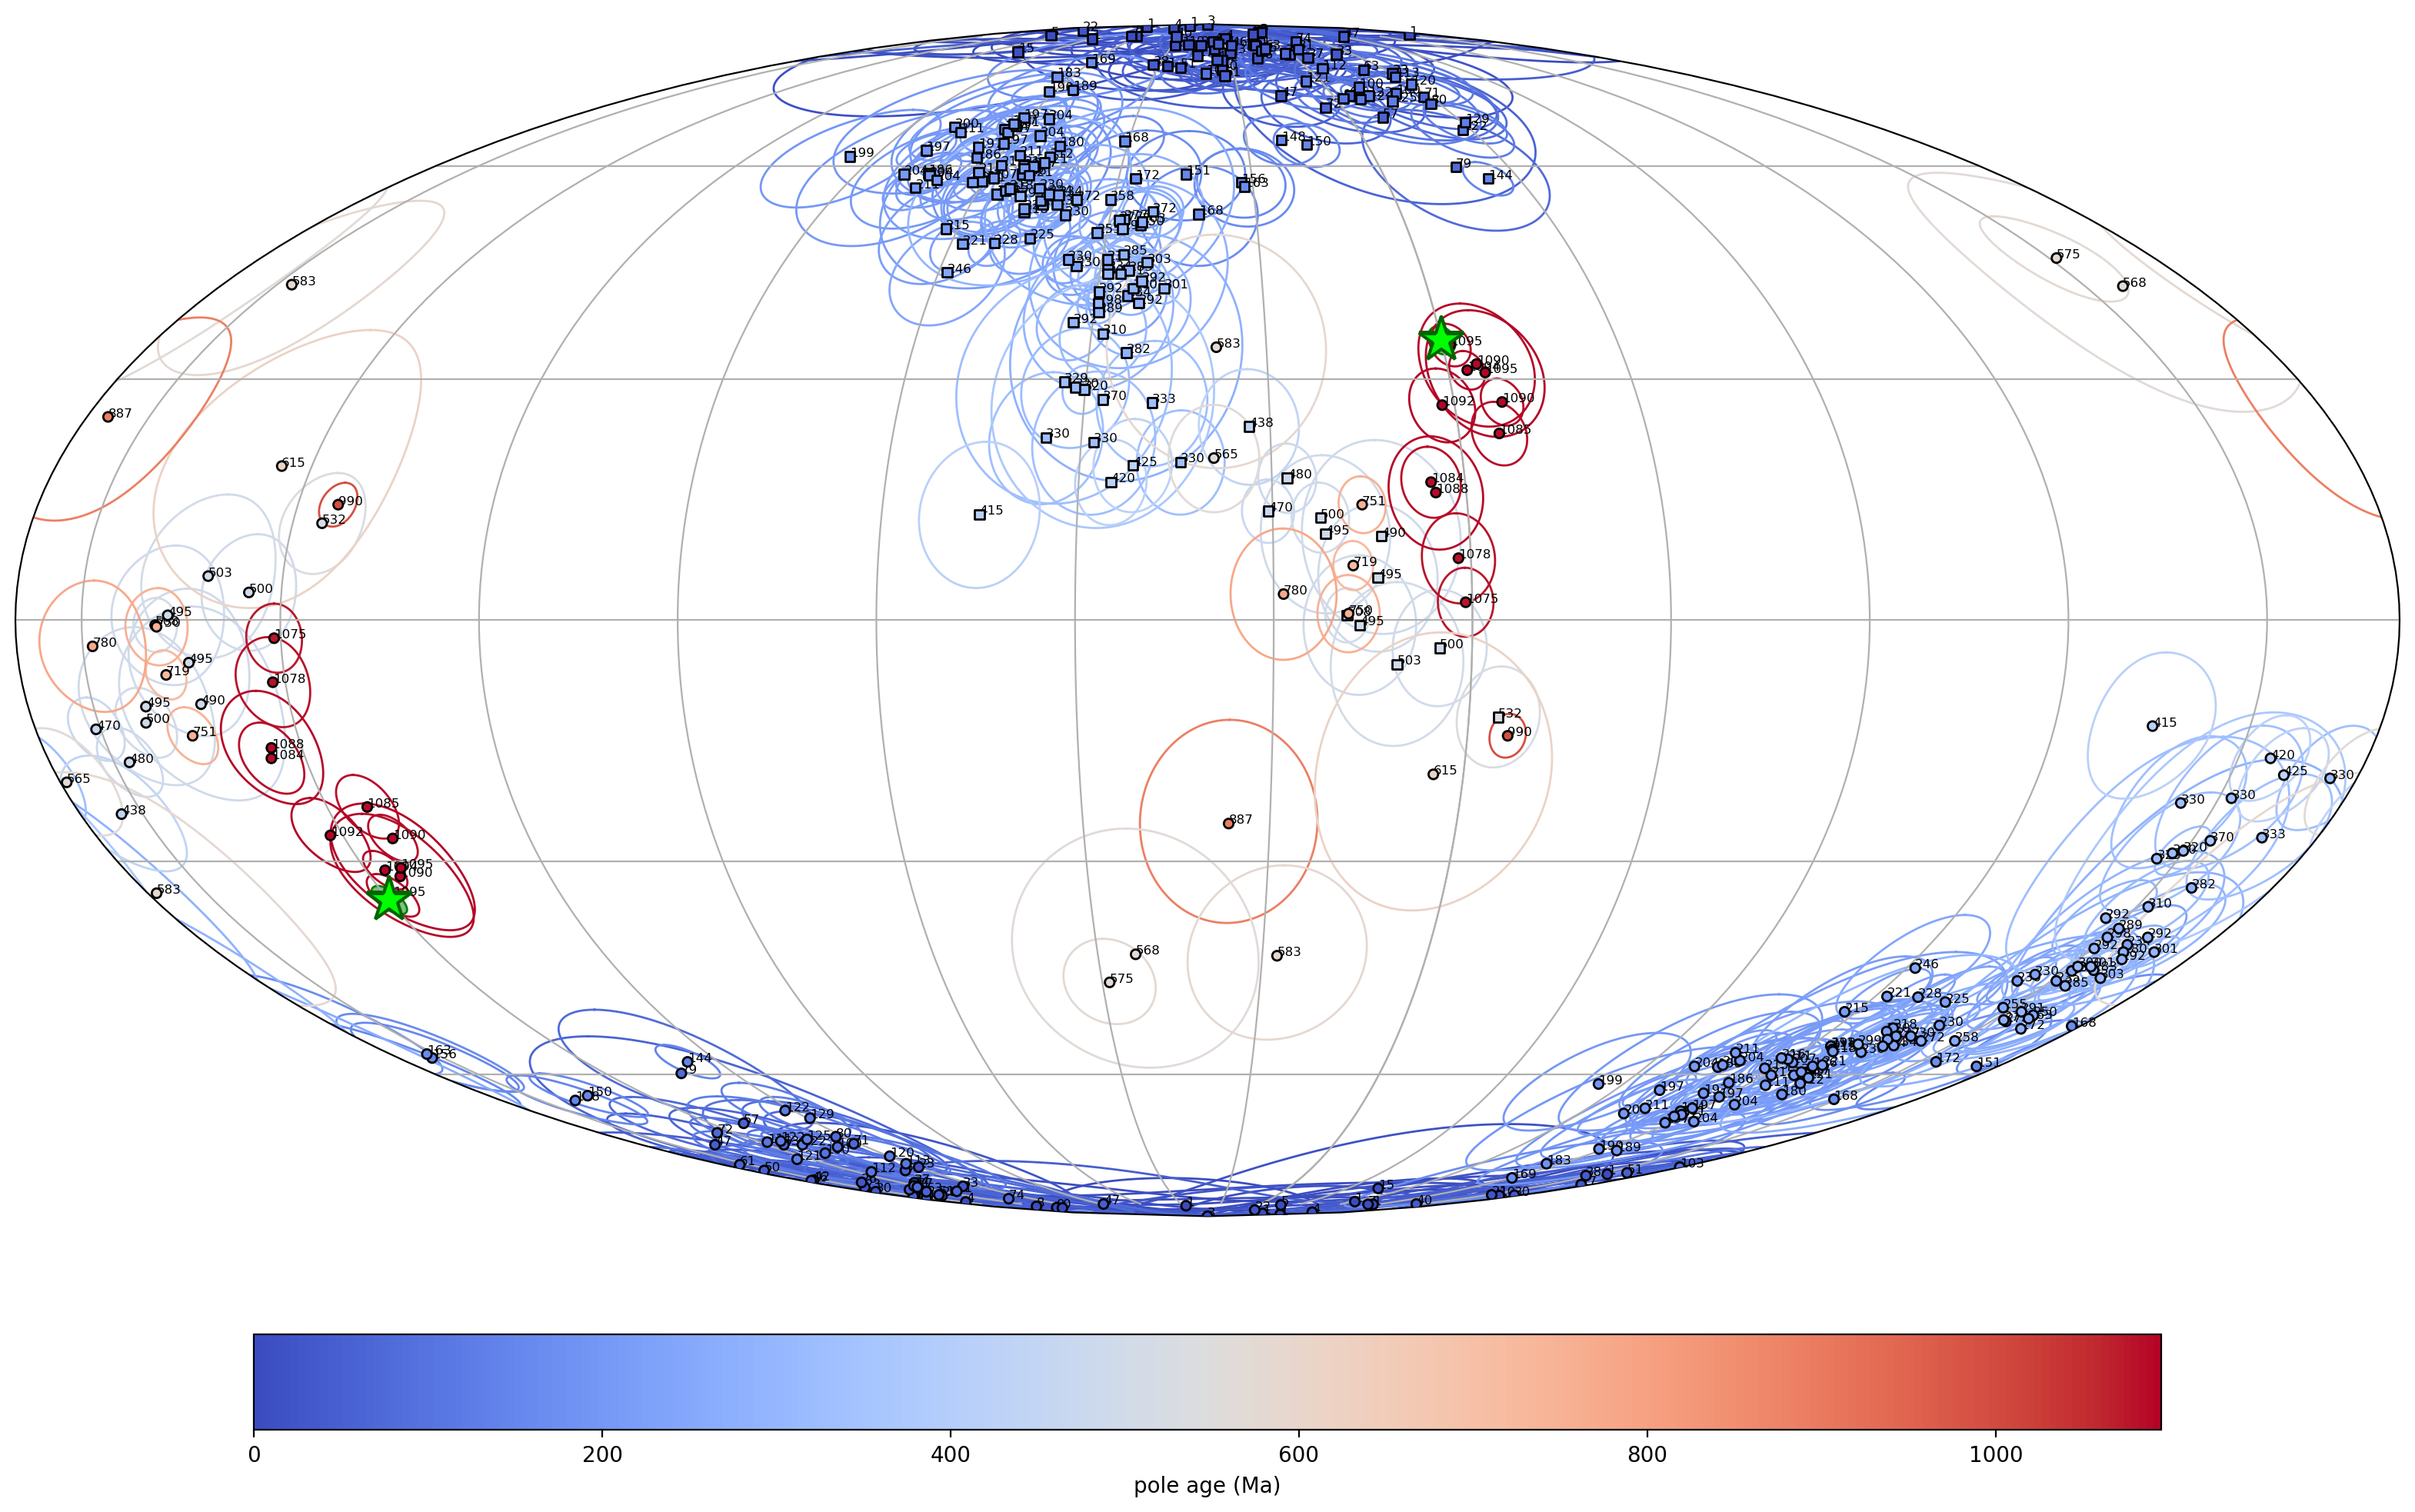

<GeoAxesSubplot:>

In [11]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('North Shore Volcanic Group', Laurentia_stricto_poles,
                     pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=1095)

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **1** | ca. 1095 Ma (1092-1098 Ma); the upper SW sequence is bracketed by U-Pb dates 1096.75-1093.94 Ma and the upper NE sequence by the 1093.38 ± 0.55 Ma Grand Marais Rhyolite (Swanson-Hysell et al., 2019). |
| 2 | Techniques and statistical analysis | **1** | AF + thermal demagnetization, PCA; the combined VGP set passes the Deenen et al. (2011) envelope (K within 10-70). |
| 3 | Magnetic mineralogy characterized | **1** | Magnetite (and minor hematite) remanence characterized in the studies (Tauxe and Kodama, 2009; Swanson-Hysell et al., 2019). |
| 4 | Field tests constrain age of magnetization | **0** | No baked-contact or fold test is applied to the upper sequences (the limbs of the regional syncline are tilt-corrected with interflow paleohorizontal). |
| 5 | Structural control / tectonic coherence | **1** | Autochthonous Lake Superior rift flank; site means tilt-corrected. |
| 6 | Presence of reversals | **0** | The pole is of single (normal) polarity; no reversal test. |
| 7 | No resemblance to younger poles | **1** | On the Keweenawan Track, distinct from younger Laurentia poles. |
| | Total | **5/7** | Grade A |

## Nordic workshop summary

The pole is reported as a single combined normal-polarity NSVG pole, as in the
prior Nordic compilation (GPMDB 9856). The site-level recreation above
incorporates the Gooseberry River section data of Swanson-Hysell et al. (2019) in
addition to the Tauxe and Kodama (2009) and Books (1972) data; the recreated pole
agrees with the published 9856 position (34.5°N/181.3°E, A95 2.8°) within their
mutual confidence limits. Because the recreation adds new (2019) site data, the
site-level recreated pole is reported here, with the published position noted for
comparison.

In [12]:
# write the MagIC contribution (sites.txt = the pole's sites; locations.txt = pole)
OUT = '../data/1095_North_Shore_Volcanic_Group/'
sites_out = normal_upper.copy()
sites_out['location'] = 'North Shore Volcanic Group'
sites_out['geologic_classes'] = 'Extrusive:Igneous'
sites_out['geologic_types'] = 'Lava Flow'
sites_out['lithologies'] = 'Basalt'
sites_out['result_type'] = 'i'
sites_out['result_quality'] = 'g'
sites_cols = ['location','site','citations','lat','lon','dir_dec','dir_inc','dir_k',
              'dir_alpha95','dir_n_samples','dir_tilt_correction','dir_polarity',
              'vgp_lat','vgp_lon','geologic_classes','geologic_types','lithologies',
              'result_type','result_quality','sequence']
with open(OUT + 'sites.txt', 'w') as f:
    f.write('tab\tsites\n')
sites_out[sites_cols].to_csv(OUT + 'sites.txt', sep='\t', index=False, mode='a')

loc_row = {'location': 'North Shore Volcanic Group', 'location_type': 'Region',
           'age': 1095, 'age_high': 1098, 'age_low': 1092, 'age_unit': 'Ma',
           'citations': 'Tauxe and Kodama, 2009:Books, 1972:Swanson-Hysell et al., 2019',
           'geologic_classes': 'Extrusive:Igneous', 'lithologies': 'Basalt',
           'lat_n': sites_out['lat'].max(), 'lat_s': sites_out['lat'].min(),
           'lon_e': sites_out['lon'].max(), 'lon_w': sites_out['lon'].min(),
           'dir_tilt_correction': 100, 'result_type': 'a', 'result_quality': 'g',
           'pole_lat': round(pole_mean['inc'], 1), 'pole_lon': round(pole_mean['dec'], 1),
           'pole_alpha95': round(pole_mean['alpha95'], 1), 'pole_k': round(pole_mean['k'], 1),
           'pole_n_sites': int(pole_mean['n']),
           'result_name': 'North Shore Volcanic Group combined normal-polarity pole'}
with open(OUT + 'locations.txt', 'w') as f:
    f.write('tab\tlocations\n')
pd.DataFrame([loc_row]).to_csv(OUT + 'locations.txt', sep='\t', index=False, mode='a')
print('wrote', OUT + 'sites.txt', 'and locations.txt')

wrote ../data/1095_North_Shore_Volcanic_Group/sites.txt and locations.txt


### Combined normal-polarity (-N) pole

| | This study (site VGPs) | Swanson-Hysell et al. (2019) | Previous Nordic compilation |
|---|---|---|---|
| Component | CRM (magnetite, minor hematite), normal | — | recalculated from all N lavas (sites above unconformity) |
| N (sites) | 118 | — | 61 |
| N (specimens) | 614 | — | 279 |
| Dec (°) | 294.8 | — | 293.9 |
| Inc (°) | 43.3 | — | 44.0 |
| k (direction) | 47.4 | — | 41.9 |
| α95 (direction, °) | 1.9 | — | — |
| Pole lat (°N) | 35.1 | — | 34.5 |
| Pole lon (°E) | 180.1 | — | 181.3 |
| A95 (°) | 1.9 | — | 2.8 |
| dp / dm (°) | — | — | 2.8 / 2.8 |

Swanson-Hysell et al. (2019) does not report a single combined normal-polarity NSVG pole; their Table 3 lists the upper NE sequence (Pole lon 181.7, Pole lat 31.1, A95 4.2, N 28) and the upper SW sequence (Pole lon 179.3, Pole lat 36.9, A95 2.1, N 78) as separate poles and gives no directional Dec/Inc/k/α95. The combined -N pole here follows the prior Nordic compilation (GPMDB 9856). The Previous Nordic compilation entry is "North Shore lavas -N" from data/Evans_et_al_2021_compilation.csv (the ED95 = 0.1 in that row is an elongation statistic, not the directional α95).


In [13]:
nsvg_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='North Shore Volcanic Group -N (combined)',
    sites=normal_upper,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='Characteristic remanent magnetization (magnetite, minor hematite); single normal polarity',
    tests='',
    gpmdb_number='9856',
    percent_reversed=0,
    demag_code=4,
    R1=1, R2=1, R3=1, R4='', R5=1, R6=0, R7=1, Grade='A',
    nominal_age=1095, lomagage=1092, himagage=1098,
    REF_method='Upper SW sequence bracketed by U-Pb 206Pb/238U dates on the 40th Ave. Icelandite (1096.75 +/- 0.28 Ma, lower bound), Two Harbors Icelandite (1096.18 +/- 0.32 Ma, within sequence) and Palisade Rhyolite (1093.94 +/- 0.28 Ma, upper bound); upper NE sequence near the 1093.38 +/- 0.55 Ma Grand Marais Rhyolite and younger than the 1097.7 +/- 2.2 Ma Devils Kettle Rhyolite (Swanson-Hysell et al., 2019; Davis and Green, 1997).',
    POLE_AUTHORS='Swanson-Hysell, N. L., Ramezani, J., Fairchild, L. M., & Rose, I. R. (with Tauxe & Kodama, 2009 and Books, 1972)',
    YEAR=2019,
    JOURNAL='GSA Bulletin',
    VOLUME='131',
    VPAGES='913-940',
    TITLE='Failed rifting and fast drifting: Midcontinent Rift development, Laurentia rapid motion and the driver of Grenvillian orogenesis',
    COMMENT='Single combined normal-polarity NSVG pole calculated from all normal-polarity upper-sequence flows (upper SW + upper NE) of Tauxe & Kodama (2009), Books (1972), and the Gooseberry River section of Swanson-Hysell et al. (2019); Documented in Swanson-Hysell et al. 2026.'
)
pt.save_nordic_summary(nsvg_summary, '1095_North_Shore_Volcanic_Group')
nsvg_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia,North Shore Volcanic Group -N (combined),GPMDB:9856,Characteristic remanent magnetization (magneti...,,100,46.3,268.7,118,614,...,1098,Upper SW sequence bracketed by U-Pb 206Pb/238U...,North Shore Volcanic Group -N (combined),"Swanson-Hysell, N. L., Ramezani, J., Fairchild...",2019,GSA Bulletin,131,913-940,Failed rifting and fast drifting: Midcontinent...,Single combined normal-polarity NSVG pole calc...
